In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Optional: make charts larger
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
df = pd.read_csv("/content/train.csv")
print("Dataset shape:", df.shape)

df.head()
df.info()

Dataset shape: (421570, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


### **Clean the Date Column**

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].min())
print(df["Date"].max())

# Sort the data
df = df.sort_values("Date")

df.head()

2010-02-05 00:00:00
2012-10-26 00:00:00


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
277665,29,5,2010-02-05,15552.08,False
277808,29,6,2010-02-05,3200.22,False
277951,29,7,2010-02-05,10820.05,False
278094,29,8,2010-02-05,20055.64,False


### **Checking Missing and Duplicate Values**

In [6]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Duplicate rows: 0


### **Create the Time-related Columns**

In [8]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter
df["Week"] = df["Date"].dt.isocalendar().week

df[["Date", "Year", "Month", "Month_Name", "Quarter"]].head()

,Date,Year,Month,Month_Name,Quarter
0,2010-02-05,2010,2,February,1
277665,2010-02-05,2010,2,February,1
277808,2010-02-05,2010,2,February,1
277951,2010-02-05,2010,2,February,1
278094,2010-02-05,2010,2,February,1


### **Calculate the Overall Weekly Sales**

In [9]:
# First aggregate sales across all stores and departments.
weekly_sales = (
    df.groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


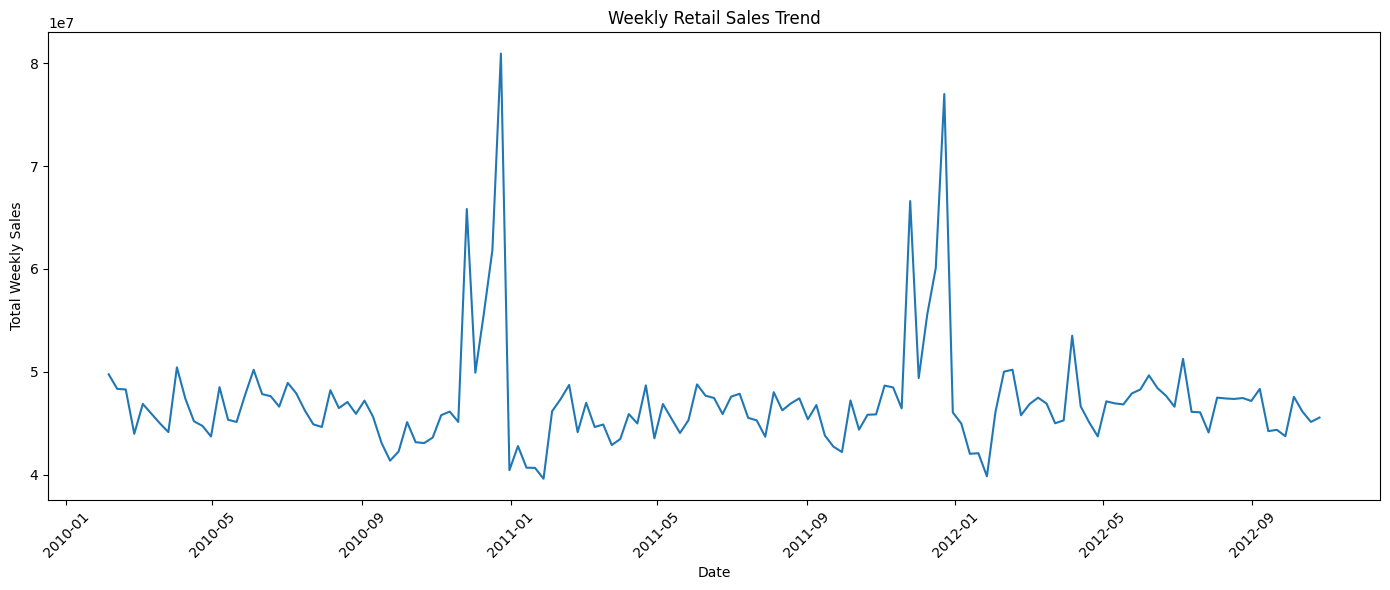

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"]
)

plt.title("Weekly Retail Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### **Aggregate sales by month**

In [11]:
monthly_sales = (
    df.set_index("Date")["Weekly_Sales"]
    .resample("ME")
    .sum()
    .reset_index()
)

monthly_sales.head()

,Date,Weekly_Sales
0,2010-02-28,1.903330e+08
1,2010-03-31,1.819198e+08
2,2010-04-30,2.314124e+08
3,2010-05-31,1.867109e+08
4,2010-06-30,1.922462e+08


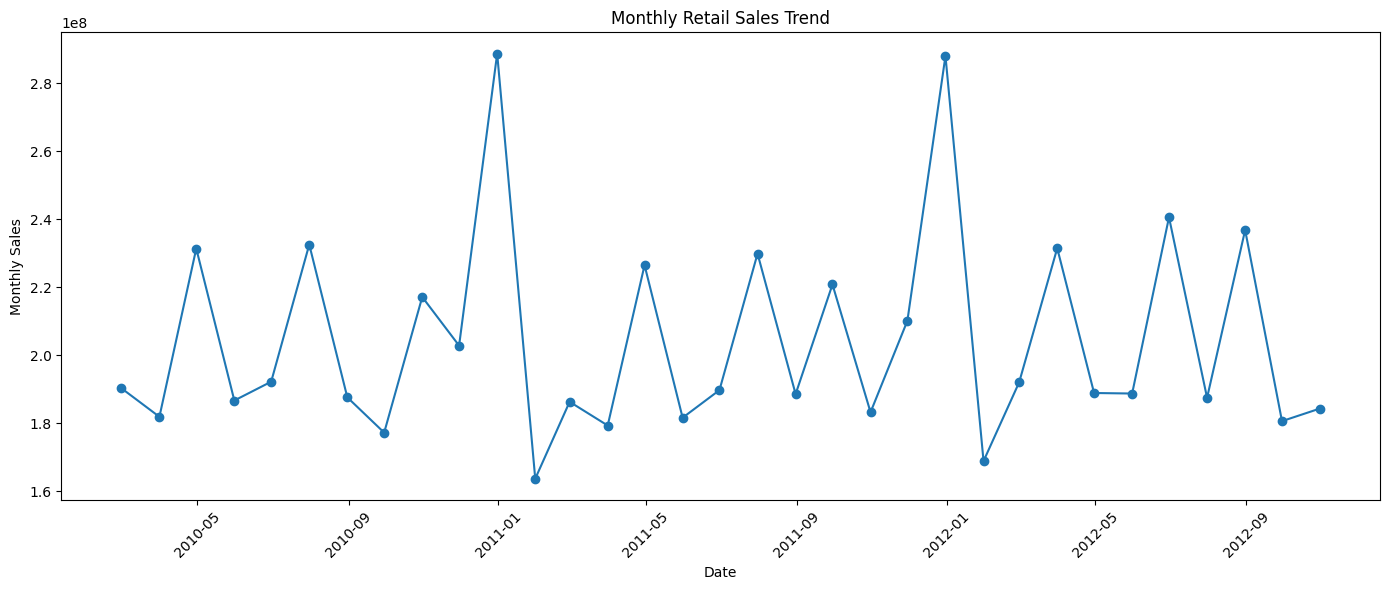

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Weekly_Sales"],
    marker="o"
)

plt.title("Monthly Retail Sales Trend")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### **Calculate a moving average**

In [15]:
# 6 month moving average
monthly_sales["6_Month_MA"] = (
    monthly_sales["Weekly_Sales"]
    .rolling(window=6)
    .mean()
)

### **Plot sales and moving averages**

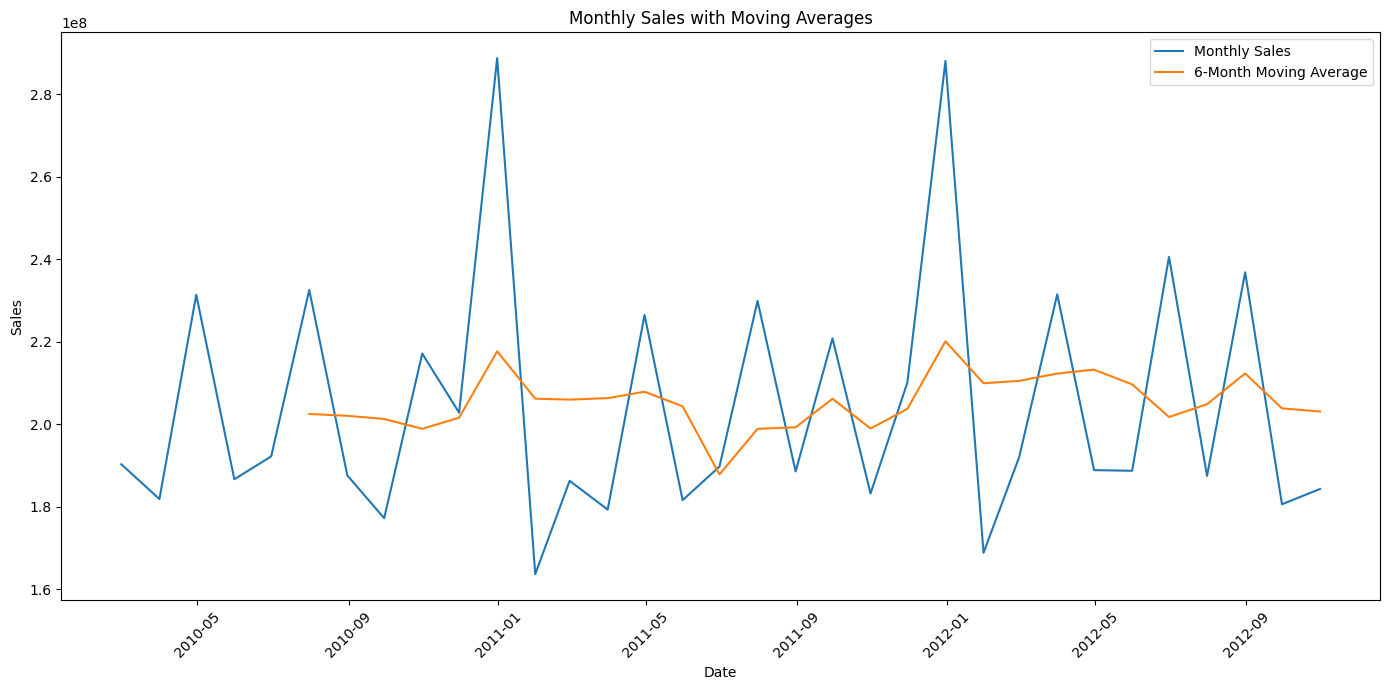

In [16]:
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Weekly_Sales"],
    label="Monthly Sales"
)

plt.plot(
    monthly_sales["Date"],
    monthly_sales["6_Month_MA"],
    label="6-Month Moving Average"
)

plt.title("Monthly Sales with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Interpretation**

The moving averages make it easier to identify the underlying trend without being distracted by individual weekly/monthly fluctuations.

### **Analyse seasonality by month**

In [17]:
monthly_seasonality = (
    df.groupby("Month")["Weekly_Sales"]
    .mean()
    .reset_index()
)

monthly_seasonality

,Month,Weekly_Sales
0,1,14126.075111
1,2,16008.779217
2,3,15416.657597
3,4,15650.338357
4,5,15776.337202
5,6,16326.137002
6,7,15861.419650
7,8,16062.516933
8,9,15095.886154
9,10,15243.855576


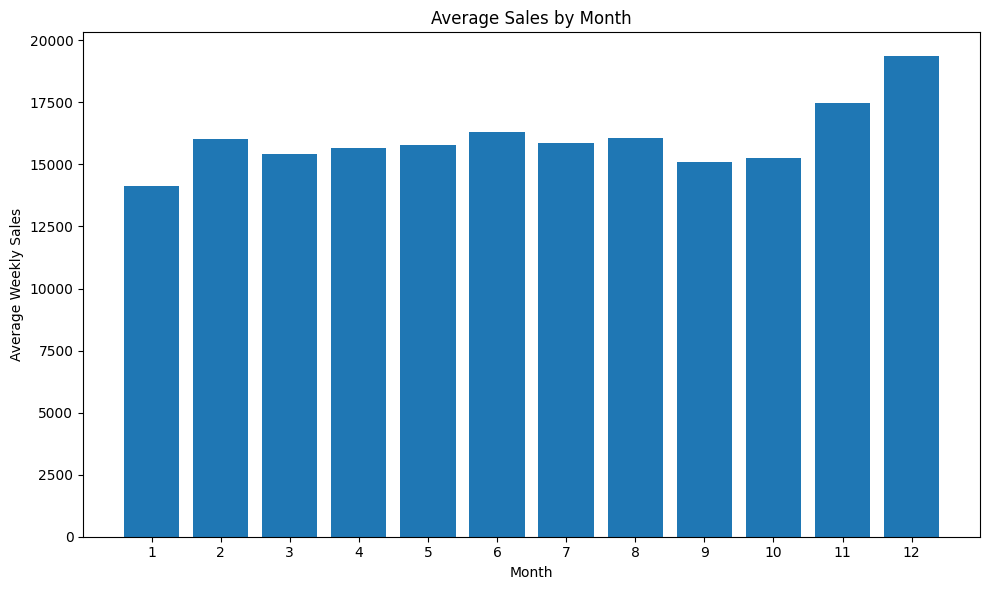

In [18]:
plt.figure(figsize=(10, 6))

plt.bar(
    monthly_seasonality["Month"],
    monthly_seasonality["Weekly_Sales"]
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### **Compare sales by year**

In [19]:
yearly_sales = (
    df.groupby("Year")["Weekly_Sales"]
    .sum()
    .reset_index()
)

yearly_sales

,Year,Weekly_Sales
0,2010,2.288886e+09
1,2011,2.448200e+09
2,2012,2.000133e+09


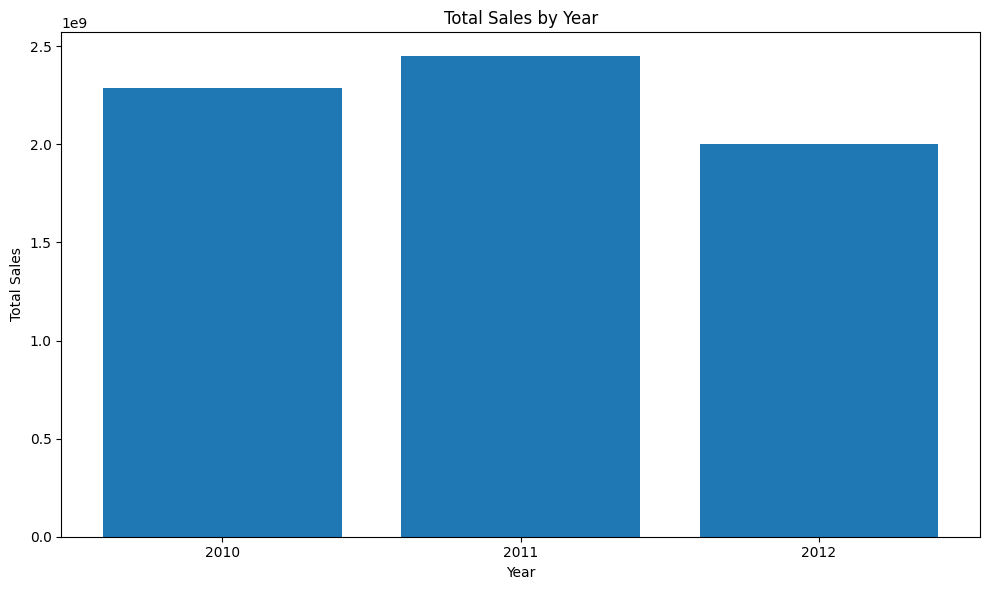

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Weekly_Sales"]
)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### **Analyse sales by department**

The dataset contains multiple departments, so we can identify the best-performing departments.

In [21]:
department_sales = (
    df.groupby("Dept")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

department_sales.head(10)

,Weekly_Sales
Dept,
92,4.839433e+08
95,4.493202e+08
38,3.931181e+08
72,3.057252e+08
90,2.910685e+08
40,2.889360e+08
2,2.806112e+08
91,2.167817e+08
13,1.973216e+08


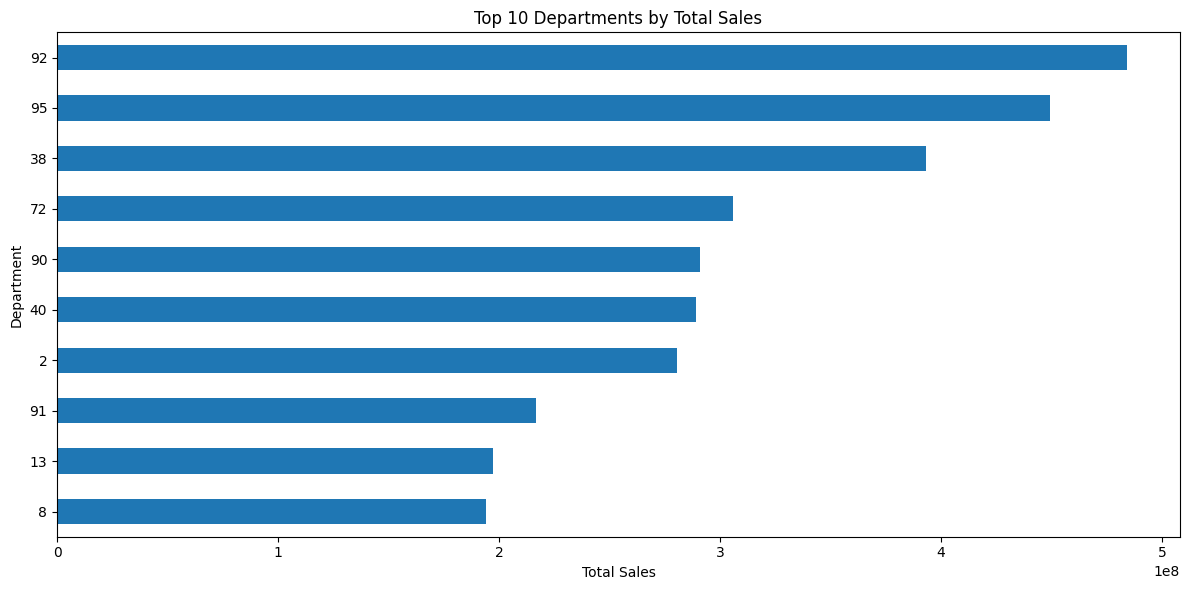

In [22]:
top_departments = department_sales.head(10)

plt.figure(figsize=(12, 6))

top_departments.sort_values().plot(kind="barh")

plt.title("Top 10 Departments by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

### **Analyze Sales by Store**

In [23]:
store_sales = (
    df.groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales.head(10)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


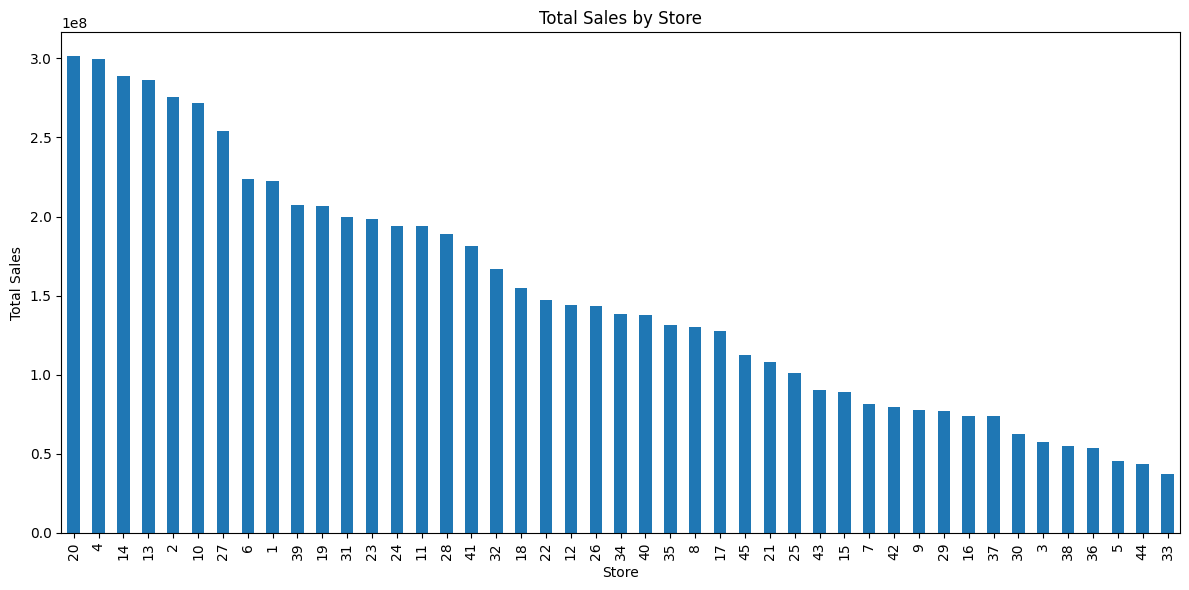

In [24]:
plt.figure(figsize=(12, 6))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### **Analyse department sales over time**

Choose one department to demonstrate the time-series behaviour.

In [25]:
dept_1 = df[df["Dept"] == 1]

dept_1_monthly = (
    dept_1.set_index("Date")["Weekly_Sales"]
    .resample("ME")
    .sum()
    .reset_index()
)

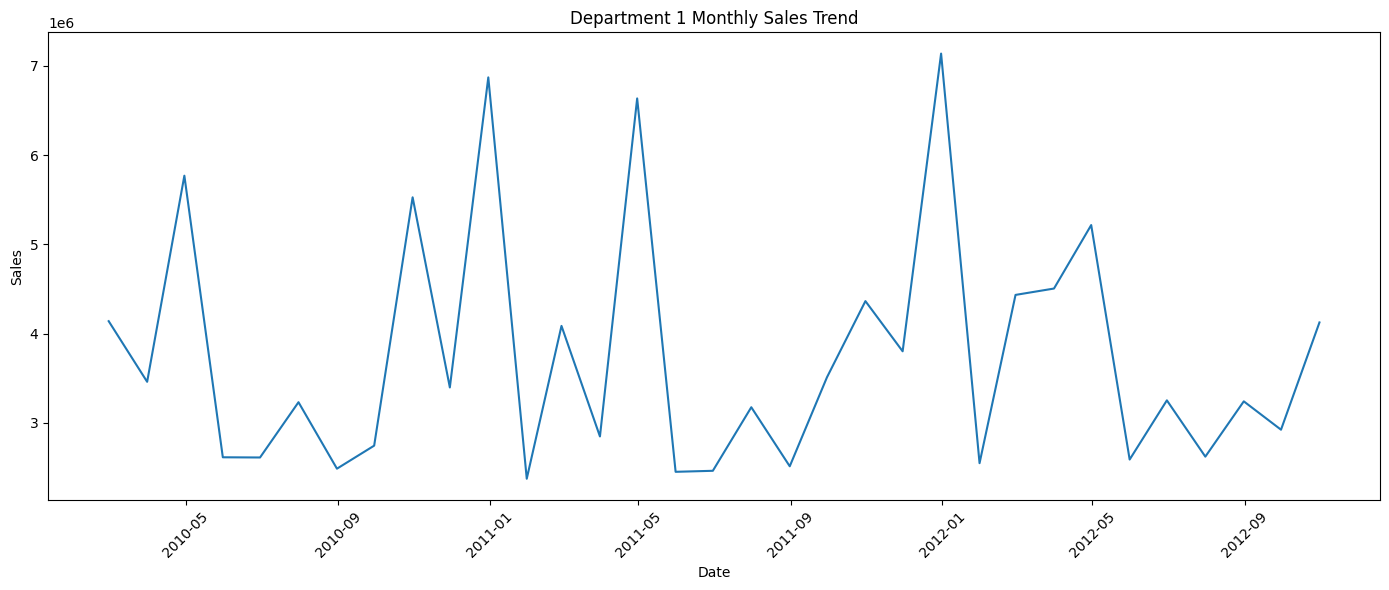

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(
    dept_1_monthly["Date"],
    dept_1_monthly["Weekly_Sales"]
)

plt.title("Department 1 Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### **Analyse store + department**

In [27]:
store_dept = df[
    (df["Store"] == 1) &
    (df["Dept"] == 1)
].copy()

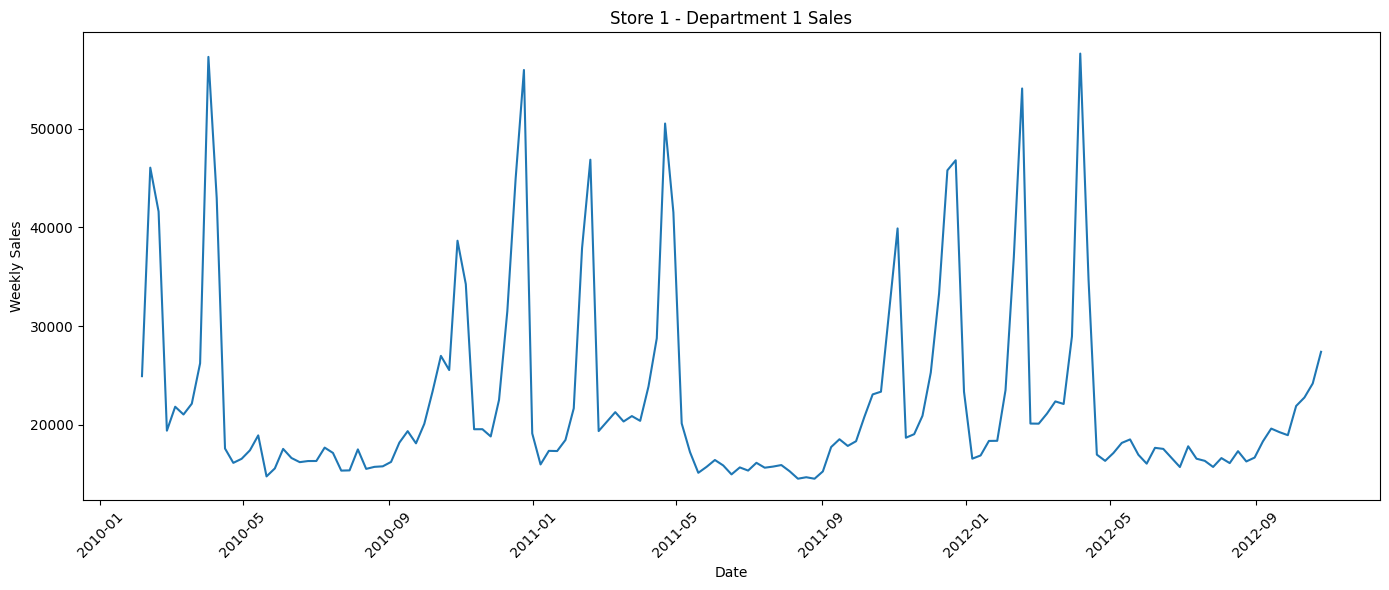

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    store_dept["Date"],
    store_dept["Weekly_Sales"]
)

plt.title("Store 1 - Department 1 Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### **Bonus: Simple exponential smoothing**

In [31]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Make Date the index
sales_ts = monthly_sales.set_index("Date")["Weekly_Sales"]

# Explicitly set monthly-end frequency
sales_ts = sales_ts.asfreq("ME")

# Build Exponential Smoothing model
model = ExponentialSmoothing(
    sales_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

# Fit model
fit = model.fit()

# Forecast next 6 months
forecast = fit.forecast(6)

print("Forecast:")
print(forecast)

Forecast:
2012-11-30    2.069494e+08
2012-12-31    2.838049e+08
2013-01-31    1.685698e+08
2013-02-28    1.913891e+08
2013-03-31    1.826792e+08
2013-04-30    2.295461e+08
Freq: ME, dtype: float64


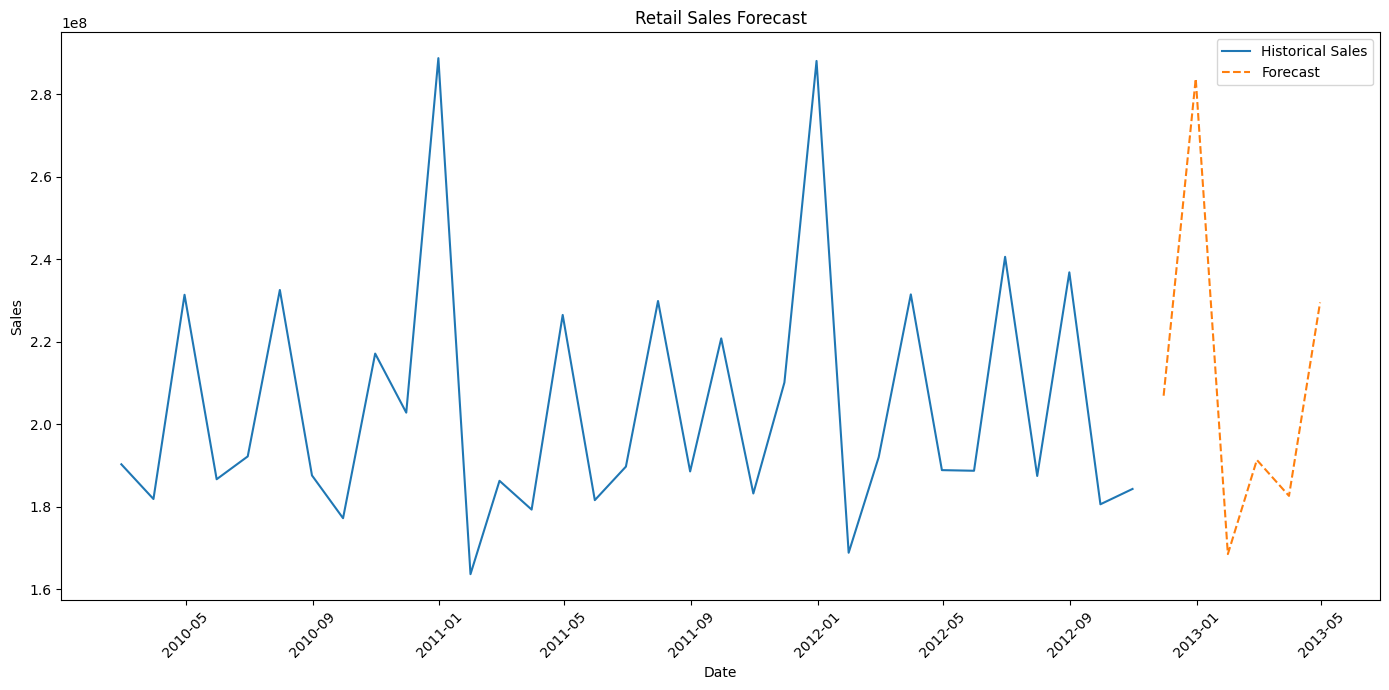

In [32]:
plt.figure(figsize=(14, 7))

plt.plot(
    sales_ts.index,
    sales_ts.values,
    label="Historical Sales"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast",
    linestyle="--"
)

plt.title("Retail Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### **Summary Table**

In [33]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Average Weekly Sales",
        "Highest Weekly Sales",
        "Lowest Weekly Sales"
    ],
    "Value": [
        df["Weekly_Sales"].sum(),
        df["Weekly_Sales"].mean(),
        df["Weekly_Sales"].max(),
        df["Weekly_Sales"].min()
    ]
})

summary

,Metric,Value
0,Total Sales,6.737219e+09
1,Average Weekly Sales,1.598126e+04
2,Highest Weekly Sales,6.930994e+05
3,Lowest Weekly Sales,-4.988940e+03


Save the cleaned dataset.

In [34]:
df.to_csv(
    "walmart_sales_cleaned.csv",
    index=False
)